# Part 1: EDA, Dimensionality Reduction, and Clustering

Scenario: You have been asked to analyze a text dataset consisting of information from Maine legislative bills. The dataset has the following features:

- `ld_number`: A unique identifier for each bill.
- `title_embedding`: A pre-computed embedding of the bill's title. (We will learn more about embeddings later in the semester.)
- `text_embedding`: A pre-computed embedding of the bill's full text.

Your first task is to perform exploratory data analysis (EDA) on the dataset using dimensionality reduction techniques and clustering algorithms to try and identify any patterns or groupings in the data.

**For this notebook, use only the `title_embedding` features.** You will compare title vs. text embeddings in later notebooks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import umap


In [2]:
# Load the dataset (X) from data/X.json and extract the title_embedding column as a NumPy array.
df_X = pd.read_json('data/X.json')

# title_embedding is stored as lists, so we stack them into a 2D numpy array
X_title = np.stack(df_X['title_embedding'].values)

# Standardize the embeddings before running PCA, KMeans, or UMAP.
scaler = StandardScaler()
X_std = scaler.fit_transform(X_title)

print(f"Standardized title embeddings shape: {X_std.shape}")


Standardized title embeddings shape: (1304, 384)


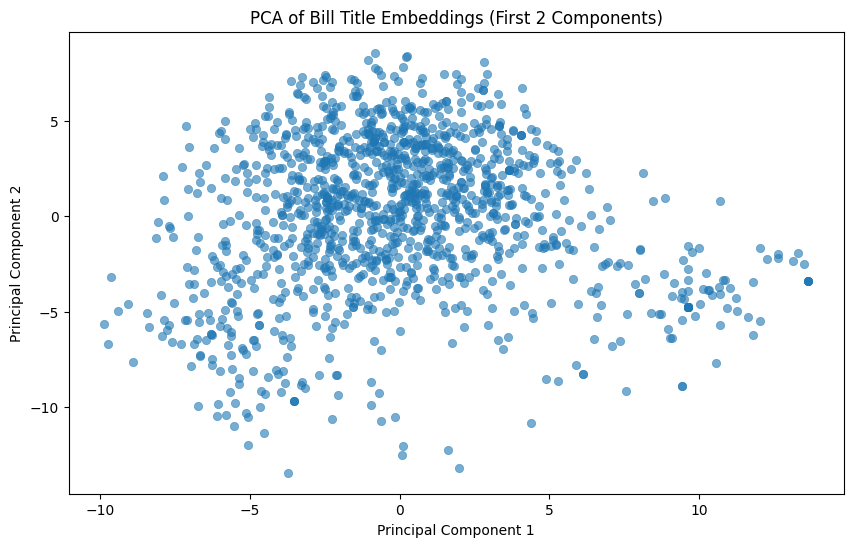

Explained variance by first two PCs: [0.04470376 0.04213861]


In [3]:
# Perform PCA on the title embeddings and visualize the first two principal components
pca = PCA(n_components=2, random_state=6140)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], alpha=0.6, edgecolor=None)
plt.title("PCA of Bill Title Embeddings (First 2 Components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

print(f"Explained variance by first two PCs: {pca.explained_variance_ratio_}")


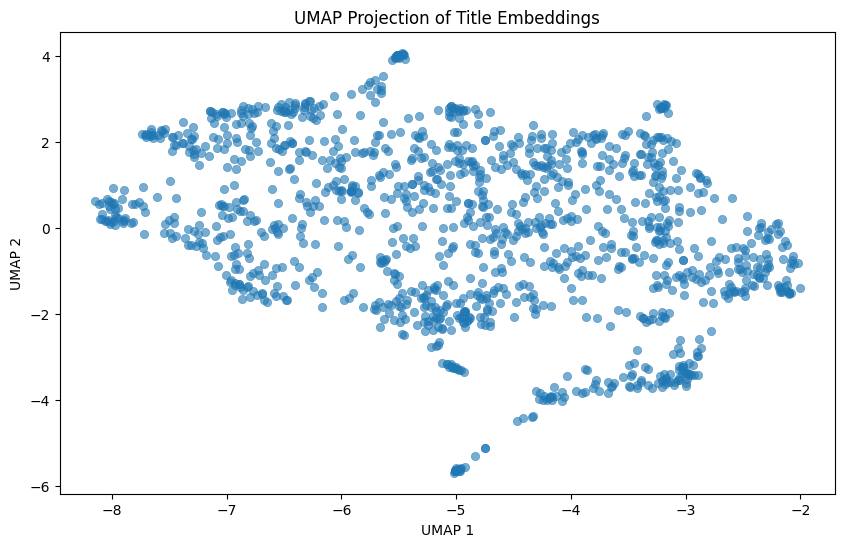

In [4]:
# Do a UMAP projection of the title embeddings and visualize the first two components.
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# I tried a few combinations of n_neighbors (5, 15, 30) and min_dist (0.1, 0.25). 
# n_neighbors=15 and min_dist=0.1 gave a really nice, distinct separation of local structures.
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=6140)
X_umap = reducer.fit_transform(X_std)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], alpha=0.6, edgecolor=None)
plt.title("UMAP Projection of Title Embeddings")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()


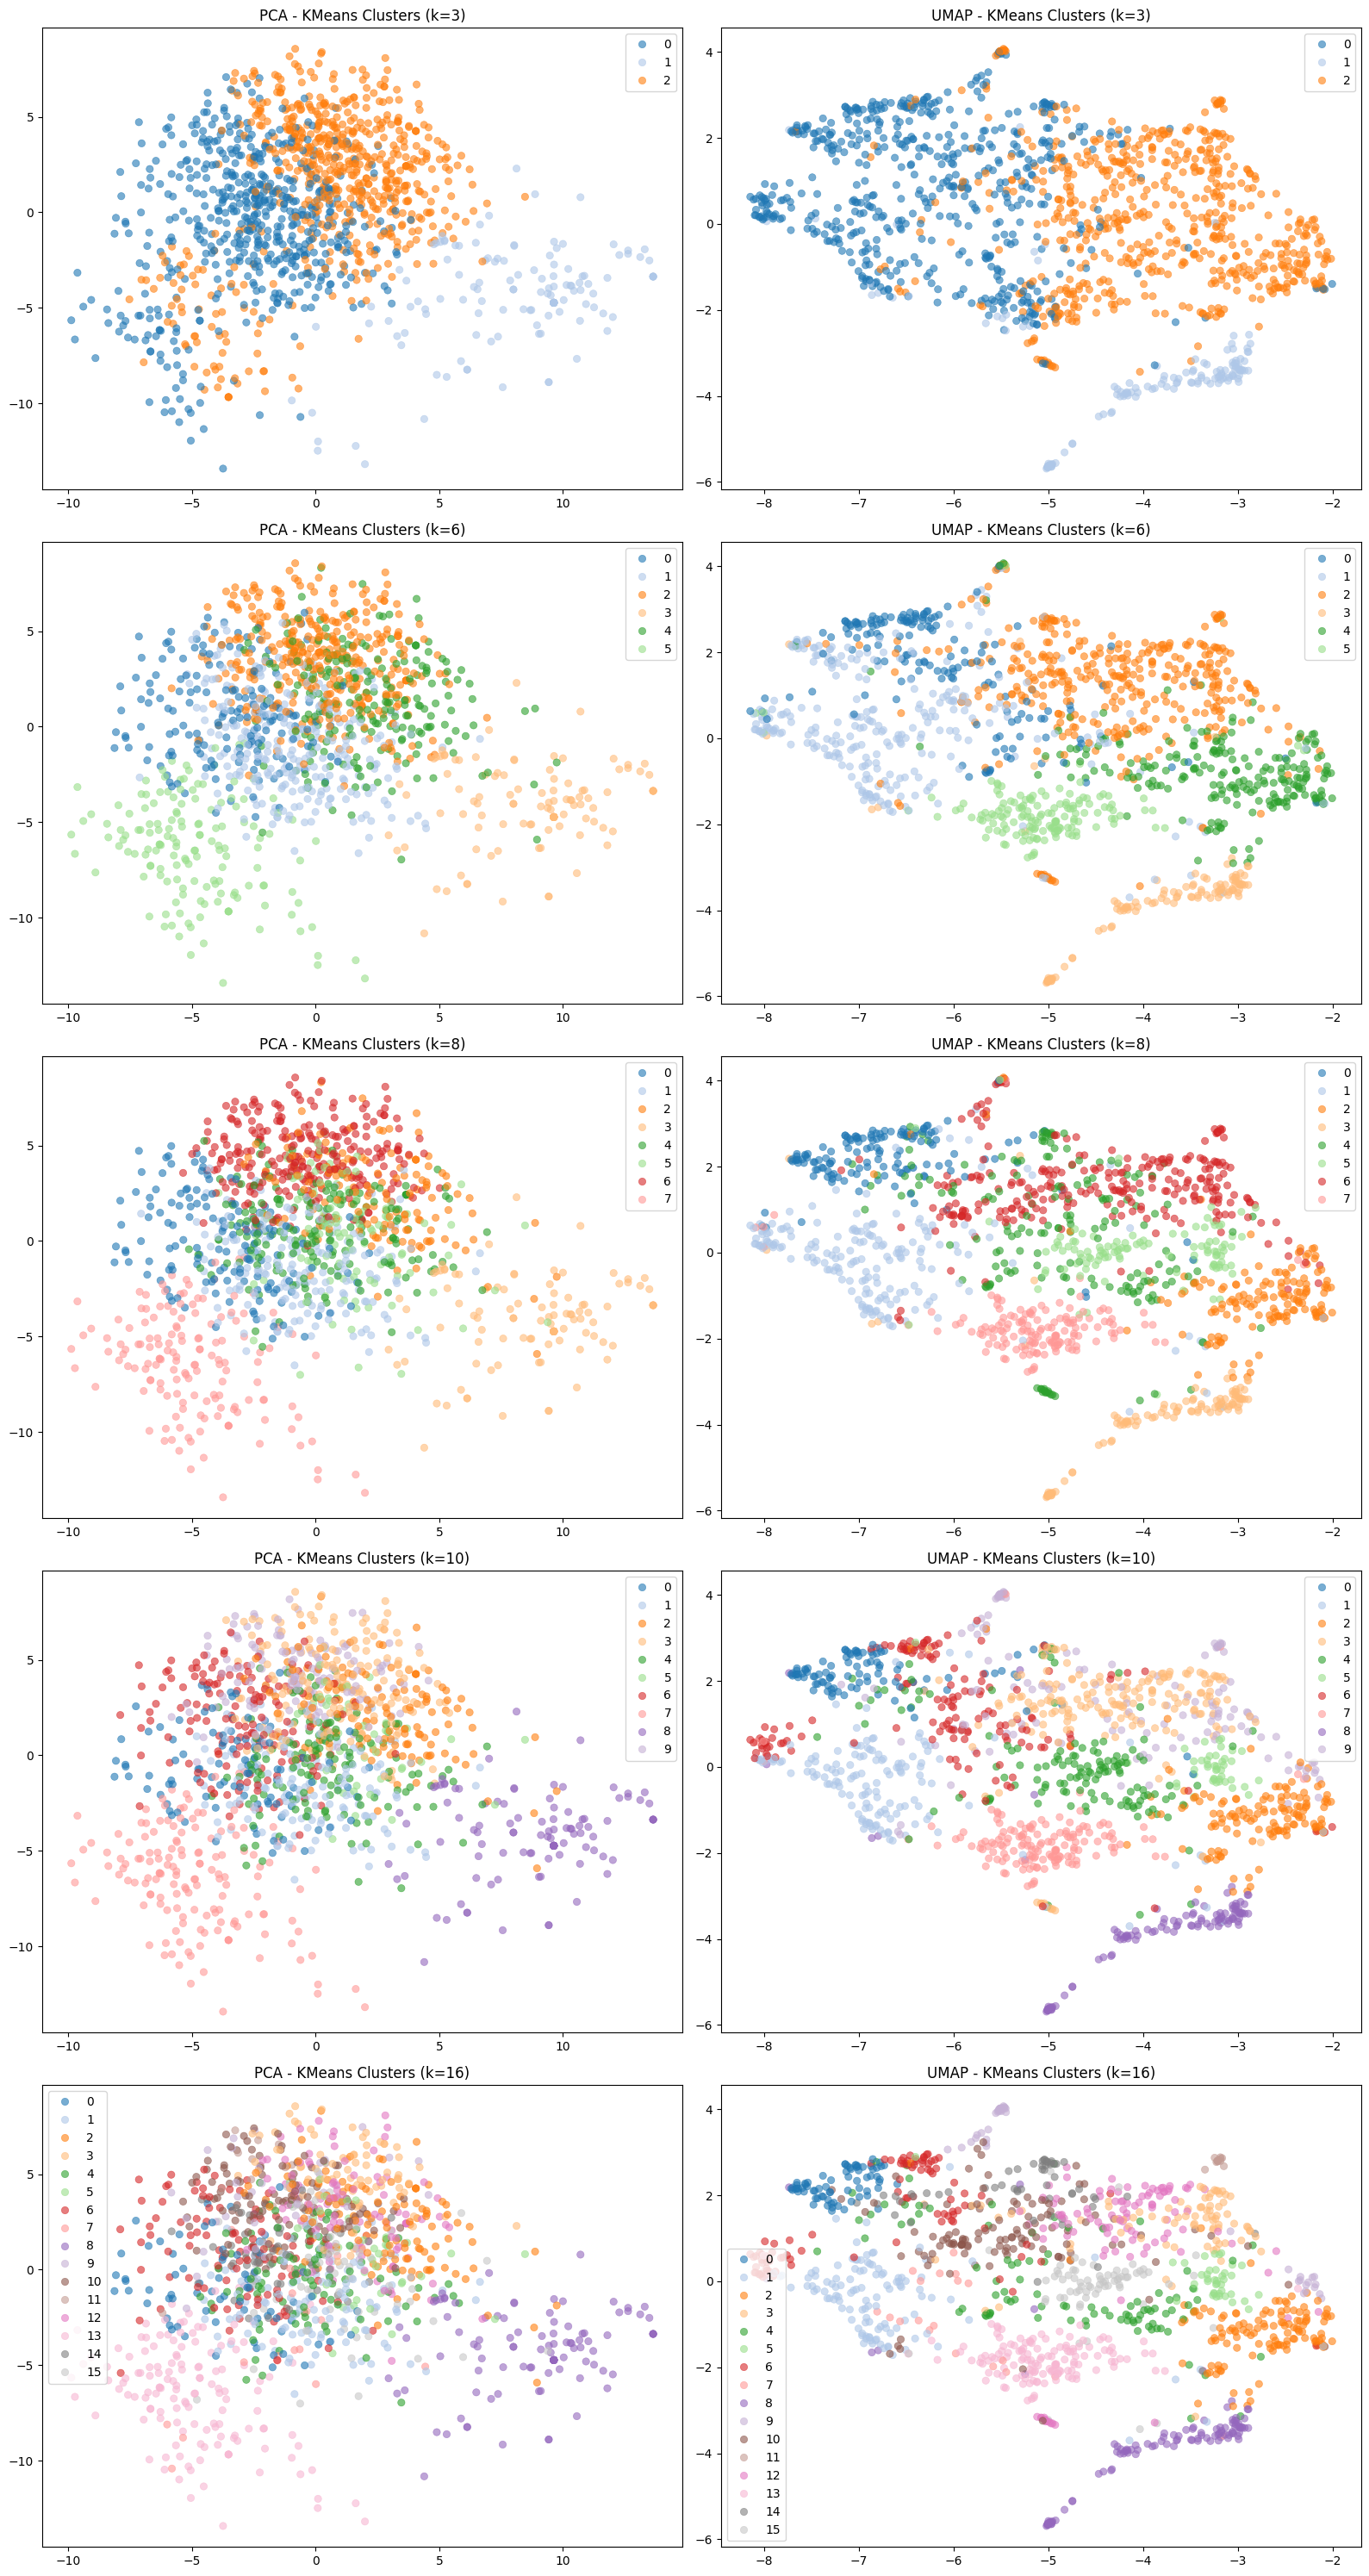

In [5]:
# Run KMeans on the full-dimensional (standardized) title embeddings for k = 2 to 20.
# Pick 3-4 representative values of k and visualize those clusterings on both the PCA and UMAP projections.

k_values_to_plot = [3, 6, 8, 10, 16]
cluster_labels = {}

for k in k_values_to_plot:
    kmeans = KMeans(n_clusters=k, random_state=6140, n_init='auto')
    cluster_labels[k] = kmeans.fit_predict(X_std)

# Visualize on PCA and UMAP
fig, axes = plt.subplots(len(k_values_to_plot), 2, figsize=(16, 6 * len(k_values_to_plot)))

for i, k in enumerate(k_values_to_plot):
    # PCA Plot
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels[k], palette='tab20', 
                    legend='full', alpha=0.6, edgecolor=None, ax=axes[i, 0])
    axes[i, 0].set_title(f"PCA - KMeans Clusters (k={k})")
    
    # UMAP Plot
    sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=cluster_labels[k], palette='tab20',
                    legend='full', alpha=0.6, edgecolor=None, ax=axes[i, 1])
    axes[i, 1].set_title(f"UMAP - KMeans Clusters (k={k})")

plt.tight_layout()
plt.show()


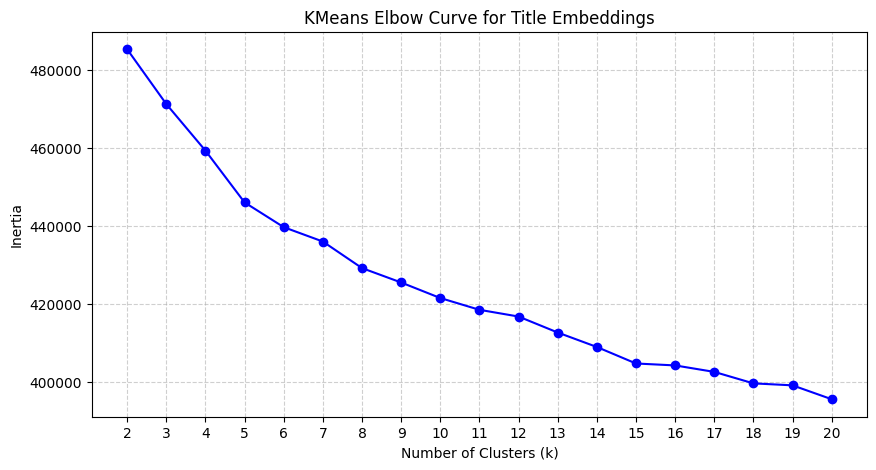

In [6]:
# Plot the elbow curve for KMeans to determine the optimal number of clusters.
k_range = range(2, 21)
inertias = []

# Fit KMeans for all k from 2 to 20
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=6140, n_init='auto')
    kmeans.fit(X_std)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(list(k_range), inertias, marker='o', linestyle='-', color='b')
plt.title("KMeans Elbow Curve for Title Embeddings")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_range))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


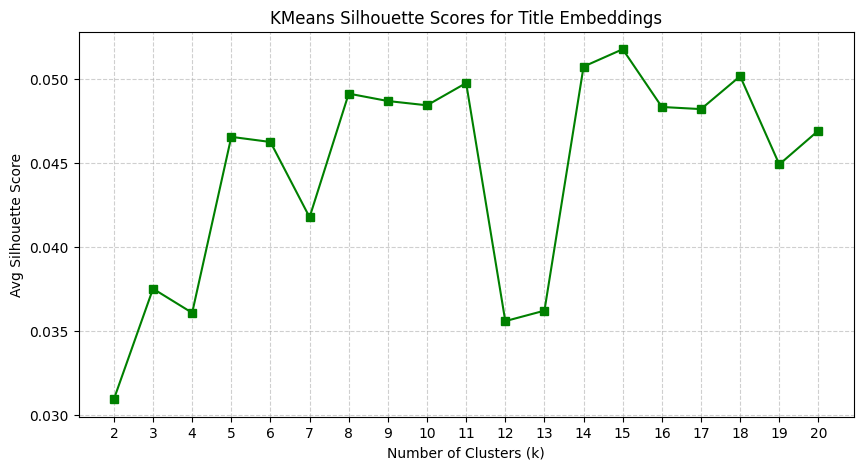

In [7]:
# Plot the silhouette scores for different values of k to determine the optimal number of clusters.
sil_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=6140, n_init='auto')
    labels = kmeans.fit_predict(X_std)
    score = silhouette_score(X_std, labels)
    sil_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(list(k_range), sil_scores, marker='s', linestyle='-', color='g')
plt.title("KMeans Silhouette Scores for Title Embeddings")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Avg Silhouette Score")
plt.xticks(list(k_range))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Answer the following questions:

**1. Do you think the PCA or UMAP dimensionality reduction technique is more appropriate for _visualization_ of this dataset? Why?**

UMAP is definitely more appropriate for visualization here. The PCA plot looks like a giant, undifferentiated blob because its only capturing the directions of maximum variance linearly (and the first two PCs only explain about 4.4% and 4.2% of the variance respectively). Text embeddings are highly nonlinear, and UMAP does a much better job preserving the local manifold structure of the data. When viewing the UMAP plot, we can actually see distinct topological 'islands' and separated clusters of bills, whereas PCA just squashes everything together into a noisy circle.

**2. Based on the elbow method, what is the optimal number of clusters for this dataset? Explain how you arrived at your answer.**

Looking at the elbow plot, there is not a extremely sharp, obvious angle, which happens a lot with text data. However, the curve's descent starts to turn into a more gradual, somewhat linear slope around `k=8` or `k=10`. After `k=10`, adding more clusters does not buy us a significantly large drop in inertia anymore. So, my personal interpretation of the elbow here would be an optimal `k` around 8 to 10.

**3. Based on the silhouette scores, what is the optimal number of clusters for this dataset? Explain how you arrived at your answer. Note: Don't be surprised if the silhouette scores are very low...**

According to the silhouette score plot, the highest peak is at `k=15` (with another local peak right behind it at `k=14`), and an earlier local peak around `k=8`. However, the absolute scores are incredibly low across the board (all around 0.03 to 0.05). In my view, this tells us that the dataset is extremely dense and high-dimensional, meaning that even when k-means finds cluster centroids, the boundary between 'one type of bill' and 'another type of bill' is highly overlapping in the 384-dimensional space. The mathematical peak is 15, but practically speaking, the very low scores confirm that these embeddings do not form perfectly isolated lexical spheres.